# GP posterior oracle (R_star) viewer

## How to run on the remote server

**Option A — VS Code Remote-SSH (interactive, recommended):** connect to this node the same way you already do over SSH, open this file in VS Code, pick the **multivariate-icl** kernel (top-right kernel picker) the first time, then just re-run the *draw* cell below (Shift+Enter) for each new oracle. Everything renders inline over the existing Remote-SSH connection — no separate port-forwarding needed.

**Option B — headless, from any plain SSH shell (no browser/VS Code needed):** from the repo root, with the `multivariate-icl` conda env activated, run:
```bash
jupyter nbconvert --to notebook --execute --inplace \
    notebooks/visualize_oracle.ipynb \
    --ExecutePreprocessor.kernel_name=multivariate-icl
```
This re-runs the whole notebook (drawing one fresh oracle) and saves the plot + metadata straight into the `.ipynb` file. Re-run the same command for the next oracle, then open/reload the file in VS Code (or any Jupyter viewer) to see the latest plot — no live kernel or port-forwarding required to *view* it, since VS Code reads the saved file directly.

---

Run the **setup** cell once, then the **kernel generation parameters** cell (edit values there to experiment), then re-run either **draw** cell (Shift+Enter) each time you want a fresh oracle under the current parameters. Editing a parameter only takes effect after you re-run the parameters cell.

In [4]:
# --- setup (run once) ---
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns
from omegaconf import OmegaConf

_REPO_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(_REPO_ROOT, "src"))

from data_gen import generate_gp_task

base_cfg = OmegaConf.create({"data": OmegaConf.load(os.path.join(_REPO_ROOT, "conf", "data", "gp_tasks.yaml"))})

counter = 0

## Kernel generation parameters (edit, then re-run this cell + a draw cell)

Starts from your real `conf/data/gp_tasks.yaml`, then applies the overrides below. Set any override to `None` to fall back to the yaml's own value. Useful if a kernel looks collapsed (e.g. `E[|r|]` near 0) or degenerate (near 1) in the grid view — widen/narrow these to compensate.

In [ ]:
# --- edit these, then re-run this cell (and a draw cell) ---
KERNEL = None            # None = use yaml's kernel/kernels; or one of:
                          # "rbf", "matern32", "cosine", "periodic", "rational_quadratic", "dot_product"
N_TEST = 16               # test points -> R_star is N_TEST x N_TEST
P_MIN, P_MAX = 50, 50            # training context size range
D_KERNEL_MIN, D_KERNEL_MAX = None, None  # active kernel columns k ~ Uniform[..]
L_MIN, L_MAX = None, 0.001            # kernel length scale range
L_LOG_UNIFORM = None      # sample l ~ LogUniform instead of Uniform
L_SCALE_BY_SQRT_K = None  # scale l range by sqrt(k active kernel dims)
ALPHA2_MIN, ALPHA2_MAX = None, None
NUGGET_MIN, NUGGET_MAX = None, None  # diagonal regulariser range

# --- build cfg from the overrides above (no need to edit below this line) ---
cfg = OmegaConf.create(OmegaConf.to_container(base_cfg, resolve=True))
_overrides = {
    "N_min": N_TEST, "N_max": N_TEST,
    "P_min": P_MIN, "P_max": P_MAX,
    "d_kernel_min": D_KERNEL_MIN, "d_kernel_max": D_KERNEL_MAX,
    "l_min": L_MIN, "l_max": L_MAX,
    "l_log_uniform": L_LOG_UNIFORM, "l_scale_by_sqrt_k": L_SCALE_BY_SQRT_K,
    "alpha2_min": ALPHA2_MIN, "alpha2_max": ALPHA2_MAX,
    "nugget_min": NUGGET_MIN, "nugget_max": NUGGET_MAX,
}
for key, value in _overrides.items():
    if value is not None:
        cfg.data[key] = value
if KERNEL is not None:
    cfg.data.kernel = KERNEL
    cfg.data.kernels = []

print("effective kernel config:")
print(OmegaConf.to_yaml(cfg.data))

effective kernel config:
d_features: 10
d_kernel_min: 1
d_kernel_max: 4
P_min: 5
P_max: 5
N_min: 16
N_max: 16
n_tasks: 5000000
l_min: 1.0
l_max: 10.0
l_log_uniform: true
l_scale_by_sqrt_k: true
alpha2_min: 0.5
alpha2_max: 2.0
nugget_min: 0.1
nugget_max: 0.25
kernel: dot_product
period_min: 0.5
period_max: 3.0
rq_alpha_min: 0.1
rq_alpha_max: 5.0
pit_eps: 1.0e-06
shard_size: 256
dataset_dir: ./data/pit_cosine_prior
pit_dir: ./data/pit_cosine_prior/pit
resume: false



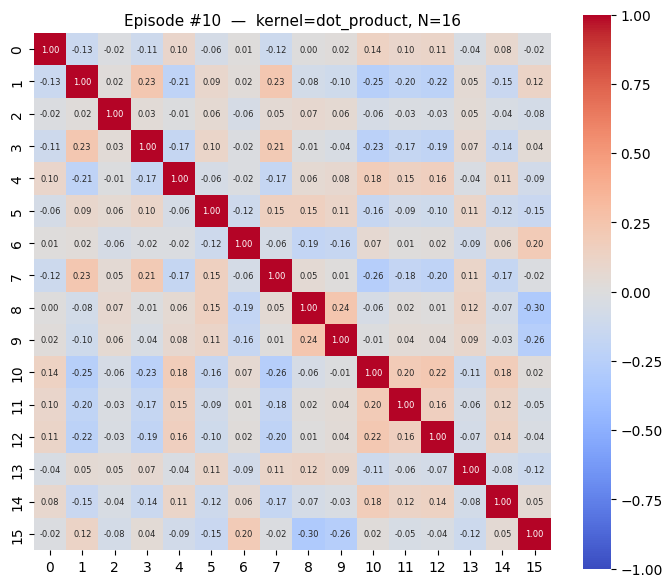

kernel: dot_product
n_train (P): 5
n_test (N): 16
length scale (l): 9.9869
alpha2: 0.0
nugget: 0.1249
kernel_feature_indices: [0, 9]


In [9]:
def draw_next_oracle():
    global counter
    counter += 1
    ep = generate_gp_task(cfg)
    R = ep["R_star"]

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        R.numpy(), ax=ax, cmap="coolwarm", center=0, vmin=-1, vmax=1,
        square=True, annot=True, fmt=".2f", annot_kws={"size": 6}, cbar=True,
    )
    ax.set_title(f"Episode #{counter}  —  kernel={ep['kernel']}, N={R.shape[0]}", fontsize=11)
    plt.tight_layout()
    plt.show()

    meta = {
        "kernel": ep["kernel"],
        "n_train (P)": int(ep["n_train"]),
        "n_test (N)": int(ep["n_test"]),
        "length scale (l)": round(float(ep["l"]), 4),
        "alpha2": round(float(ep["alpha2"]), 4),
        "nugget": round(float(ep["nugget"]), 4),
        "kernel_feature_indices": ep["kernel_feature_indices"].tolist(),
    }
    if ep["kernel"] == "periodic":
        meta["period"] = round(float(ep["period"]), 4)
    if ep["kernel"] == "rational_quadratic":
        meta["rq_alpha"] = round(float(ep["rq_alpha"]), 4)
    for k, v in meta.items():
        print(f"{k}: {v}")


# --- draw (re-run this cell for the next oracle) ---
draw_next_oracle()

## Grid view — 8 oracles at once

Instead of stepping through one at a time, this shows a batch side by side so you can get a feel for the range of what's generated. Re-run the cell below for a fresh batch of 8.

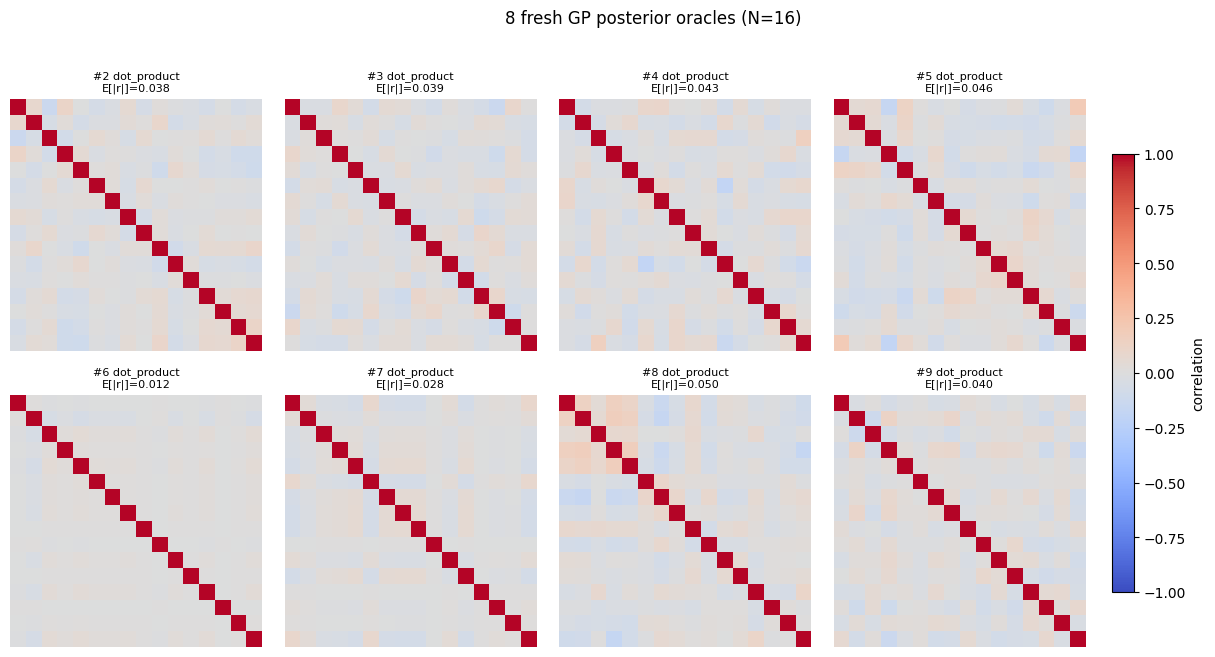

In [7]:
import numpy as np
import torch


def draw_oracle_grid(n_matrices: int = 8, n_cols: int = 4):
    global counter
    n_rows = -(-n_matrices // n_cols)  # ceil
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols + 0.6, 3.2 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    episodes = []
    mesh = None
    for ax in axes[:n_matrices]:
        counter += 1
        ep = generate_gp_task(cfg)
        episodes.append(ep)
        R = ep["R_star"]
        mask = ~torch.eye(R.shape[0], dtype=torch.bool)
        mean_abs = R[mask].abs().mean().item()

        sns.heatmap(
            R.numpy(), ax=ax, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, cbar=False, xticklabels=False, yticklabels=False,
        )
        mesh = ax.collections[0]
        ax.set_title(f"#{counter} {ep['kernel']}\nE[|r|]={mean_abs:.3f}", fontsize=8)

    for ax in axes[n_matrices:]:
        ax.axis("off")

    fig.suptitle(f"{n_matrices} fresh GP posterior oracles (N={N_TEST})", y=1.02)
    fig.tight_layout()
    fig.colorbar(mesh, ax=axes[:n_matrices].tolist(), shrink=0.8, label="correlation", pad=0.02)
    plt.show()
    return episodes


# --- draw grid (re-run this cell for a fresh batch) ---
_ = draw_oracle_grid(n_matrices=8, n_cols=4)